# He Red (667 nm) Zeeman Effect — Splitting Images

This notebook analyzes the **red line** from single splitting-measurement images (normal Zeeman triplet: σ⁻, π, σ⁺).

Images: `vdc_20_splitting_measurements.png`, `vdc_22.5_splitting_measurements.png`, etc.

VDC → B (kG): 20→5.97, 22.5→6.15, 25→7.35, 27.5→8.05, 29→9.3

In [21]:
%matplotlib inline
from pathlib import Path
import numpy as np

data_dir = Path('.').resolve()
cache_dir = data_dir

# VDC values and B field mapping (kG)
vdc_vals = np.array([20, 22.5, 25, 27.5, 29])
B_FIELDS_KG = np.array([5.97, 6.15, 7.35, 8.05, 9.3], dtype=float)

# Image filenames (one per VDC): vdc_20_splitting_measurements.png, vdc_22.5_splitting_measurements.png, ...
image_names = []
for v in vdc_vals:
    if v == int(v):
        image_names.append(f'vdc_{int(v)}_splitting_measurements.png')
    else:
        image_names.append(f'vdc_{v}_splitting_measurements.png')
image_paths = [data_dir / name for name in image_names]

missing = [p for p in image_paths if not p.exists()]
if missing:
    raise FileNotFoundError('Missing files:\n' + '\n'.join(str(p) for p in missing))

etalon_thickness_cm = 0.811

print('Cache dir:', cache_dir)
print('Images:', [p.name for p in image_paths])

Cache dir: C:\Users\Aditi\Physics111B\ATM\zeeman
Images: ['vdc_20_splitting_measurements.png', 'vdc_22.5_splitting_measurements.png', 'vdc_25_splitting_measurements.png', 'vdc_27.5_splitting_measurements.png', 'vdc_29_splitting_measurements.png']


In [22]:
from zeeman_analysis_pipeline import load_or_compute_profiles

# Preprocess and cache (or load if cache exists)
# Note: cache uses r_arr.npy, I_r_arr.npy - will overwrite if different image set!
I_r_arr, r_arr, centers = load_or_compute_profiles(
    image_paths=[str(p) for p in image_paths],
    cache_dir=cache_dir,
    force_recompute=False,
    nbins=2000,
    verbose=True,
    center_step=2,
)

n_profiles = len(r_arr)
print('Cached profiles:', n_profiles)
if centers is not None:
    print('Centers shape:', centers.shape)

Cached profiles: 5
Centers shape: (5, 2)


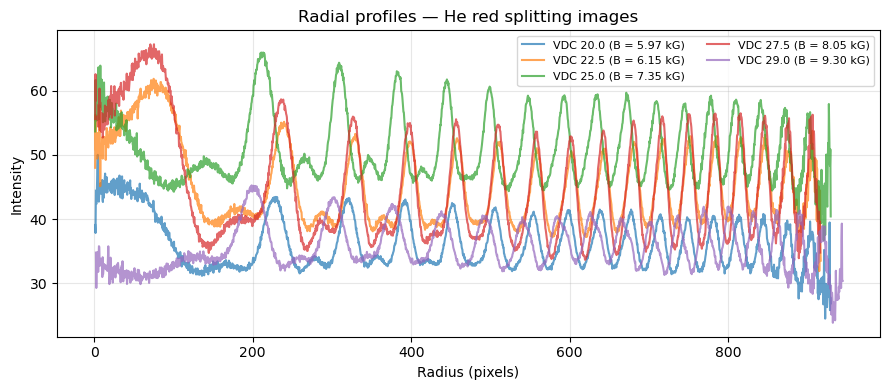

In [23]:
# Plot radial profiles overlaid (one per VDC)
import matplotlib.pyplot as plt

r_list = [np.asarray(r, dtype=float) for r in r_arr]
I_list = [np.asarray(i, dtype=float) for i in I_r_arr]

fig, ax = plt.subplots(figsize=(9, 4))
for idx in range(n_profiles):
    r = r_list[idx]
    I = I_list[idx]
    B_kG = float(B_FIELDS_KG[idx])
    ax.plot(r, I, alpha=0.7, label=f"VDC {vdc_vals[idx]} (B = {B_kG:.2f} kG)")
ax.set_xlabel("Radius (pixels)")
ax.set_ylabel("Intensity")
ax.set_title("Radial profiles — He red splitting images")
ax.legend(ncol=2, fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

In [24]:
from zeeman_analyze import run_analysis, plot_results, AnalyzeConfig

config = AnalyzeConfig(
    cache_dir=cache_dir,
    B_fields=B_FIELDS_KG,
    B_scale=1000.0,  # kG -> G
    etalon_thickness_cm=etalon_thickness_cm,
    use_triplet=True,
    out_ring_csv=cache_dir / 'zeeman_red_ringwise.csv',
    out_summary_csv=cache_dir / 'zeeman_red_summary.csv',
    out_plot=cache_dir / 'zeeman_red_vs_B.png',
)

df_ring, df_summary, magneton = run_analysis(config)

df_ring.to_csv(config.out_ring_csv, index=False)
df_summary.to_csv(config.out_summary_csv, index=False)
plot_results(df_summary, magneton, config.out_plot)

print('Saved:', config.out_ring_csv)
print('Saved:', config.out_summary_csv)
print('Saved:', config.out_plot)
magneton

Saved plot to C:\Users\Aditi\Physics111B\ATM\zeeman\zeeman_red_vs_B.png
Saved: C:\Users\Aditi\Physics111B\ATM\zeeman\zeeman_red_ringwise.csv
Saved: C:\Users\Aditi\Physics111B\ATM\zeeman\zeeman_red_summary.csv
Saved: C:\Users\Aditi\Physics111B\ATM\zeeman\zeeman_red_vs_B.png


{'slope_cm_inv_per_G': 3.94509069383303e-06,
 'slope_unc': 1.3795610182235726e-05,
 'intercept_cm_inv': 0.08637440925522213,
 'intercept_unc': 0.10150423346541003,
 'slope_through_origin': 1.5267233313439384e-05,
 'mu_B_J_per_T': 7.836709064841415e-25,
 'mu_B_unc_J_per_T': 2.7404232693343737e-24,
 'mu_B_through_origin_J_per_T': 3.0327532365607777e-24,
 'component_factor': 1.0,
 'n_points': 5,
 'accepted_mu_B': 9.2740100783e-24}